## Introduction: Keynes, Friedman, Modigliani

[![badge](https://img.shields.io/badge/Launch%20using%20-Econ--ARK-blue)](https://econ-ark.org/materials/keynesfriedmanmodigliani#launch)

In [1]:
# Some initial setup
from HARK.ConsumptionSaving.ConsIndShockModel import PerfForesightConsumerType
import pandas_datareader.data as web
import statsmodels.formula.api as sm
import scipy.stats as stats
import datetime as dt
import pandas as pd
from matplotlib import pyplot as plt
import numpy as np

plt.style.use("seaborn-v0_8-darkgrid")
palette = plt.get_cmap("Dark2")


pd.core.common.is_list_like = pd.api.types.is_list_like

In [2]:
# Setup for PS1 question 3 part 1

# variances for workers
sigmaPermW = 0.01
sigmaTransW = 0.02

# Scenario A
sigmaPermFA = sigmaPermW
sigmaTransFA = 3*sigmaTransW

# Scenario B
sigmaPermFB = 10*sigmaPermW
sigmaTransFB = 3*sigmaTransW

# Scenario C
sigmaPermFC = 0.1*sigmaPermW
sigmaTransFC = 3*sigmaTransW

In [3]:
# Simulations

# non-farm workers
permW = np.random.normal(1.0, np.sqrt(sigmaPermW), 50)
transW = np.random.normal(0, np.sqrt(sigmaTransW), 50)
totalW = permW + transW

slopeW, interceptW, r_valueW, p_valueW, std_errW = stats.linregress(
    totalW, permW
)

# farm workers in scenario A
permFA = np.random.normal(1.0, np.sqrt(sigmaPermFA), 50)
transFA = np.random.normal(0, np.sqrt(sigmaTransFA), 50)
totalFA = permFA + transFA

slopeFA, interceptFA, r_valueFA, p_valueFA, std_errFA = stats.linregress(
    totalFA, permFA
)

# farm workers in scenario B
permFB = np.random.normal(1.0, np.sqrt(sigmaPermFB), 50)
transFB = np.random.normal(0, np.sqrt(sigmaTransFB), 50)
totalFB = permFB + transFA

slopeFB, interceptFB, r_valueFB, p_valueFB, std_errFB = stats.linregress(
    totalFB, permFB
)

# farm workers in scenario C
permFC = np.random.normal(1.0, np.sqrt(sigmaPermFC), 50)
transFC = np.random.normal(0, np.sqrt(sigmaTransFC), 50)
totalFC = permFC + transFC

slopeFC, interceptFC, r_valueFC, p_valueFC, std_errFC = stats.linregress(
    totalFC, permFC
)

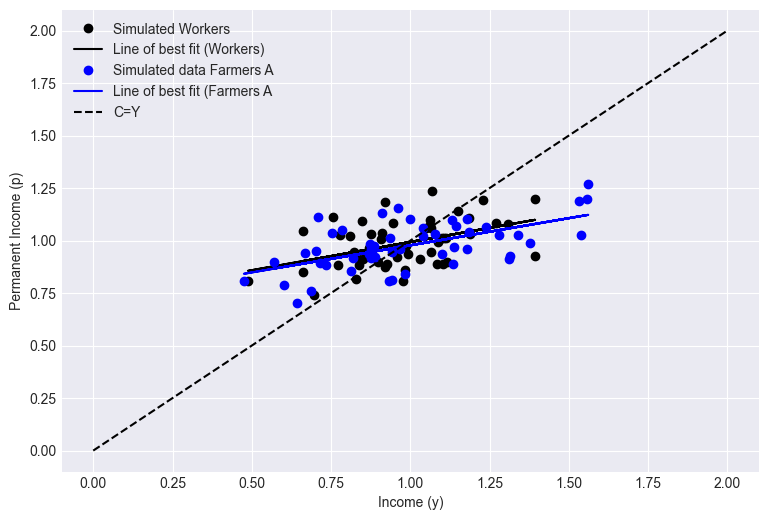

Worker's a_0 is 0.72
Worker's a_1 is 0.27
Farmer's a_0 is 0.72
Farmer's a_1 is 0.26


In [4]:
plt.figure(figsize=(9, 6))
plt.plot(
    totalW, permW, "ko", label="Simulated Workers"
)
plt.plot(totalW, interceptW + slopeW * totalW, "k-", label="Line of best fit (Workers)")
plt.plot(
    totalFA, permFA, "bo", label="Simulated data Farmers A"
)
plt.plot(totalFA, interceptFA + slopeFA * totalFA, "b-", label="Line of best fit (Farmers A")
plt.plot(np.linspace(0, 2, 5), np.linspace(0, 2, 5), "k--", label="C=Y")
plt.xlabel("Income (y)")
plt.ylabel("Permanent Income (p)")
plt.legend()
plt.savefig("Figures/PS1Fig1A.png")
plt.show()

print("Worker's a_0 is {:.2f}".format(interceptW))
print("Worker's a_1 is {:.2f}".format(slopeW))
print("Farmer's a_0 is {:.2f}".format(interceptFA))
print("Farmer's a_1 is {:.2f}".format(slopeFA))

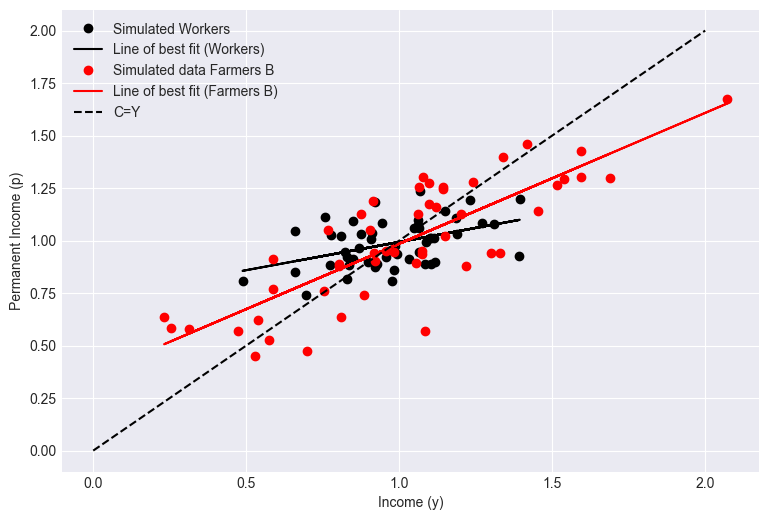

Worker's a_0 is 0.72
Worker's a_1 is 0.27
Farmer's a_0 is 0.36
Farmer's a_1 is 0.62


In [5]:
plt.figure(figsize=(9, 6))
plt.plot(
    totalW, permW, "ko", label="Simulated Workers"
)
plt.plot(totalW, interceptW + slopeW * totalW, "k-", label="Line of best fit (Workers)")
plt.plot(
    totalFB, permFB, "ro", label="Simulated data Farmers B"
)
plt.plot(totalFB, interceptFB + slopeFB * totalFB, "r-", label="Line of best fit (Farmers B)")
plt.plot(np.linspace(0, 2, 5), np.linspace(0, 2, 5), "k--", label="C=Y")
plt.xlabel("Income (y)")
plt.ylabel("Permanent Income (p)")
plt.legend()
plt.savefig("Figures/PS1Fig1B.png")
plt.show()

print("Worker's a_0 is {:.2f}".format(interceptW))
print("Worker's a_1 is {:.2f}".format(slopeW))
print("Farmer's a_0 is {:.2f}".format(interceptFB))
print("Farmer's a_1 is {:.2f}".format(slopeFB))

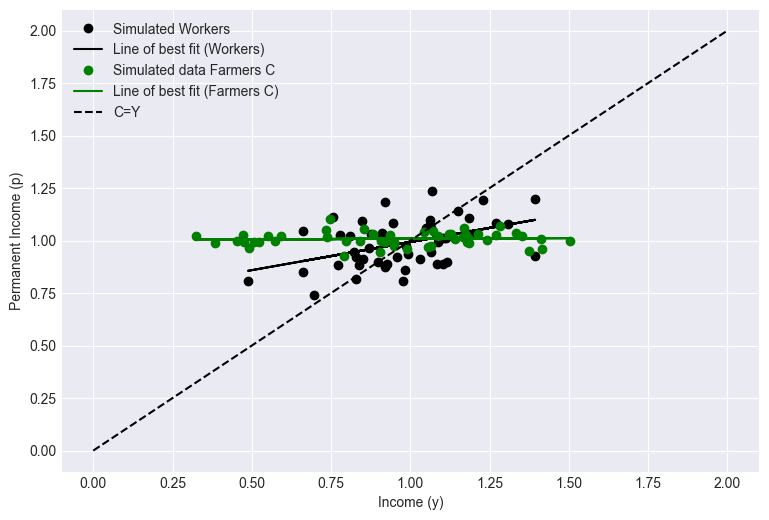

Worker's a_0 is 0.72
Worker's a_1 is 0.27
Farmer's a_0 is 1.00
Farmer's a_1 is 0.01


In [6]:
plt.figure(figsize=(9, 6))
plt.plot(
    totalW, permW, "ko", label="Simulated Workers"
)
plt.plot(totalW, interceptW + slopeW * totalW, "k-", label="Line of best fit (Workers)")
plt.plot(
    totalFC, permFC, "go", label="Simulated data Farmers C"
)
plt.plot(totalFC, interceptFC + slopeFC * totalFC, "g-", label="Line of best fit (Farmers C)")
plt.plot(np.linspace(0, 2, 5), np.linspace(0, 2, 5), "k--", label="C=Y")
plt.xlabel("Income (y)")
plt.ylabel("Permanent Income (p)")
plt.legend()
plt.savefig("Figures/PS1Fig1C.png")
plt.show()

print("Worker's a_0 is {:.2f}".format(interceptW))
print("Worker's a_1 is {:.2f}".format(slopeW))
print("Farmer's a_0 is {:.2f}".format(interceptFC))
print("Farmer's a_1 is {:.2f}".format(slopeFC))

In [7]:
# Setup for PS1 question 3 part 2

# variances for workers
sigmaPerm = 0.01
sigmaTrans = 0.2


In [8]:
# Simulations

# period t
perm = np.random.normal(1.0, np.sqrt(sigmaPerm), 200)
transt = np.random.normal(0, np.sqrt(sigmaTrans), 200)
totalt = perm + transt

# period t + 1
transt1 = np.random.normal(0, np.sqrt(sigmaTrans), 200)
totalt1 = perm + transt1

# consumption = permanent income, so 
savingst = totalt - perm

# income growth
gtotal = totalt1 - totalt

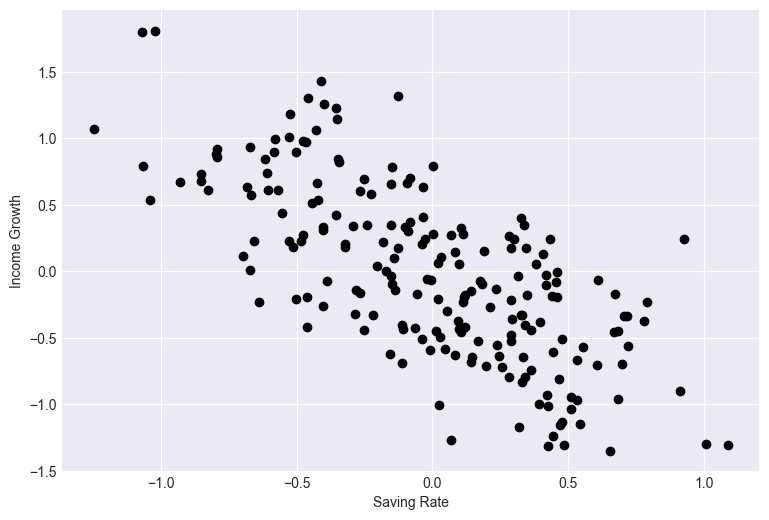

In [9]:
plt.figure(figsize=(9, 6))
plt.plot(
    savingst, gtotal, "ko"
)
plt.xlabel("Saving Rate")
plt.ylabel("Income Growth")
plt.savefig("Figures/PS1Fig2.png")
plt.show()


In [10]:
# Setup for PS1 question 3 part 3

# variances for shocks
sigmaPerm = 0.2
sigmaTrans = 1.0

In [11]:
# Simulations

# white HH
permW = 5
transW = np.random.normal(0, np.sqrt(sigmaTrans), 50)
totalW = permW + transW

# black HH
permB = 3
transB = np.random.normal(0, np.sqrt(sigmaTrans),50)
totalB = permB + transB

# consumption = permanent income, so 
savingsW = (totalW - permW)/totalW
savingsB = (totalB - permB)/totalB


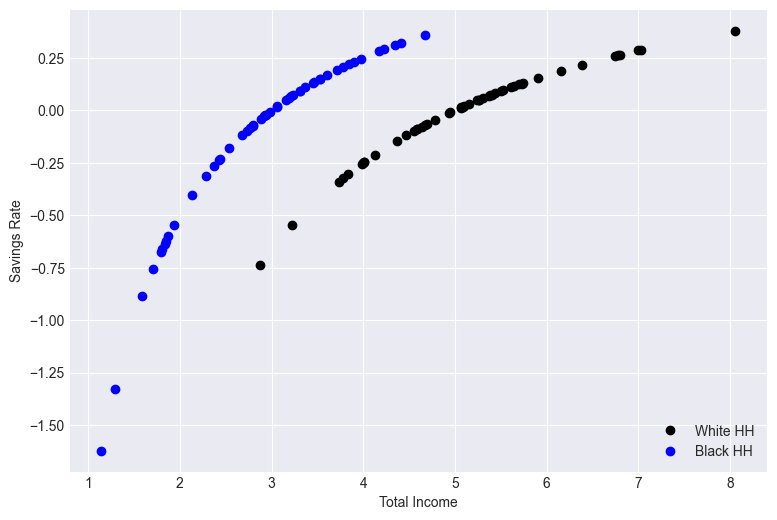

In [12]:
plt.figure(figsize=(9, 6))
plt.plot(totalW, savingsW, "ko", label = "White HH")
plt.plot(totalB, savingsB, "bo", label = "Black HH")
plt.ylabel("Savings Rate")
plt.xlabel("Total Income")
plt.legend(loc='lower right')
plt.savefig("Figures/PS1Fig3.png")
plt.show()
